In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report

In [4]:
df=pd.read_csv("data.csv")

In [5]:

df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [5]:

X=df.drop("diagnosis", axis=1)
y=df["diagnosis"]

In [6]:

num_cols=X.select_dtypes(include=['int64','Float64']).columns
cat_cols=X.select_dtypes(include=['object']).columns
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [7]:



numeric_features=['id','radius_mean','texture_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean','compactness_mean','concave_points','symmetry_mean','fractal_dimension_mean','radius_se','texture_se','perimeter_se','area_se','smoothness_se','compactness_se','concativity_se','concave points_se','fractal_dimension_worst'] 
                  
categorical_features=['diagnosis']

In [8]:

numeric_Pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

In [9]:

categorical_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [10]:


preprocessor =ColumnTransformer([
    ('num', numeric_Pipeline,numeric_features),
    ('cat', categorical_pipeline,categorical_features)
])

In [11]:

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', KNeighborsClassifier())
])



In [12]:

param_grid = {
    'model__n_neigbors':[3,5,7],
    'model__weights':['uniform','distance'],
    'model__p':[1,2]
}


In [15]:

grid=GridSearchCV(
   estimator= Pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'

)

In [18]:

print("Best_model:")
grid.fit=(X_train,y_train)


Best_model:


In [20]:
best_model=grid.best_estimator_
print(best_model)

AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'

In [19]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5
)

print(cv_scores)

NameError: name 'best_model' is not defined

In [17]:

print(cv_scores.mean())

NameError: name 'cv_scores' is not defined

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report

In [3]:
df=pd.read_csv("insurance 3.csv")

In [4]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
X=df.drop("charges", axis=1)
y=df["charges"]

In [6]:
num_cols=X.select_dtypes(include=['int64','Float64']).columns
cat_cols=X.select_dtypes(include=['object']).columns

C:\Users\USER\AppData\Local\Temp\ipykernel_3652\1256542620.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=X.select_dtypes(include=['object']).columns


In [7]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [8]:
numeric_features=['age','bmi','children','chargess']
categorical_features=['sex','smoker','region']

numeric_Pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

In [9]:
categorical_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [10]:
preprocessor =ColumnTransformer([
    ('num', numeric_Pipeline,numeric_features),
    ('cat', categorical_pipeline,categorical_features)
])

In [11]:
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', KNeighborsClassifier())
])


In [12]:
param_grid = {
    'model__n_neigbors':[3,5,7],
    'model__weights':['uniform','distance'],
    'model__p':[1,2]
}

In [13]:
grid=GridSearchCV(
    Pipeline,
    param_grid,
    cv=5,
    scoring='accuracy'

)

In [14]:
print("Best_model:")

Best_model:


In [15]:
grid.fit=X_train,y_train

In [16]:

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5
)

NameError: name 'best_model' is not defined

In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    StratifiedKFold, cross_val_score
)

from sklearn.naive_bayes import MultinomialNB


from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    confusion_matrix, roc_auc_score
)
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
df = pd.read_csv("email.csv")  
print(df.head())

  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5573 non-null   str  
 1   Message   5573 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


,Category,Message
count,5573,5573
unique,3,5158
top,ham,"Sorry, I'll call later"
freq,4825,30


In [5]:

df['Category'] = df['Category'].str.strip().str.lower()

df = df[df['Category'].isin(['ham', 'spam'])]

df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})

print(df.isnull().sum())

Category    0
Message     0
dtype: int64


In [6]:
df

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [7]:

X = df['Message']
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [9]:

model = MultinomialNB()
model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [10]:
y_pred = model.predict(X_test_vec)

In [11]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9919282511210762
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       966
           1       1.00      0.94      0.97       149

    accuracy                           0.99      1115
   macro avg       1.00      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



In [12]:
sample = ["Congratulations! You won a free ticket"]
sample_vec = vectorizer.transform(sample)

prediction = model.predict(sample_vec)

print("Spam" if prediction[0] == 1 else "Not Spam")

Spam


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib


In [20]:
df=pd. read_csv("Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [21]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(440, 8)


In [22]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None


In [23]:
print(df.describe())

          Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000000    440.000000   
mean     1.322727    2.543182   12000.297727   5796.265909   7951.277273   
std      0.468052    0.774272   12647.328865   7380.377175   9503.162829   
min      1.000000    1.000000       3.000000     55.000000      3.000000   
25%      1.000000    2.000000    3127.750000   1533.000000   2153.000000   
50%      1.000000    3.000000    8504.000000   3627.000000   4755.500000   
75%      2.000000    3.000000   16933.750000   7190.250000  10655.750000   
max      2.000000    3.000000  112151.000000  73498.000000  92780.000000   

             Frozen  Detergents_Paper    Delicassen  
count    440.000000        440.000000    440.000000  
mean    3071.931818       2881.493182   1524.870455  
std     4854.673333       4767.854448   2820.105937  
min       25.000000          3.000000      3.000000  
25%      742.250000        256.750000    408.

In [24]:
print(df.isnull().sum())

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


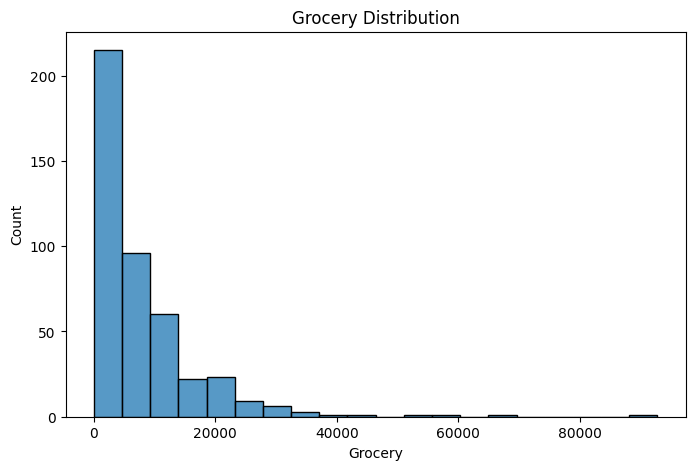

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(df['Grocery'], bins=20)
plt.title("Grocery Distribution")
plt.show()

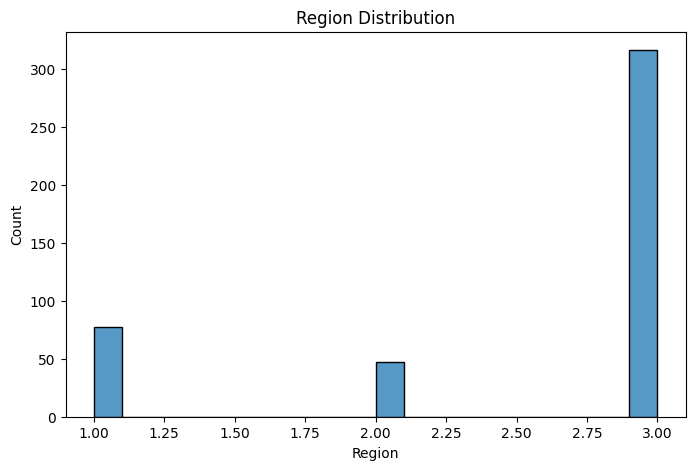

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(df['Region'], bins=20)
plt.title("Region Distribution")
plt.show()

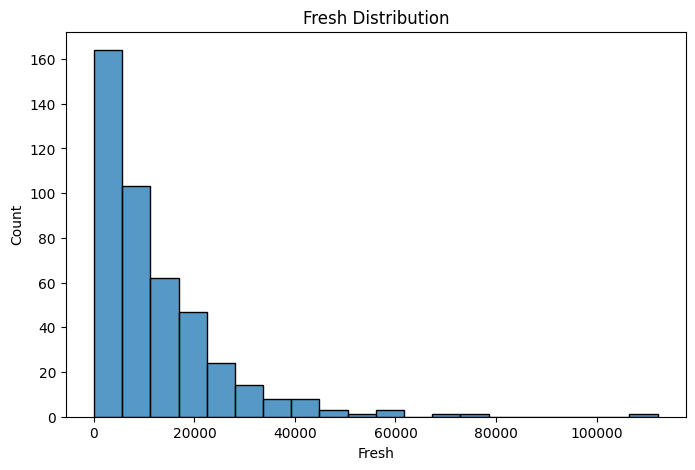

In [50]:
plt.figure(figsize=(8,5))
sns.histplot(df['Fresh'], bins=20)
plt.title("Fresh Distribution")
plt.show()

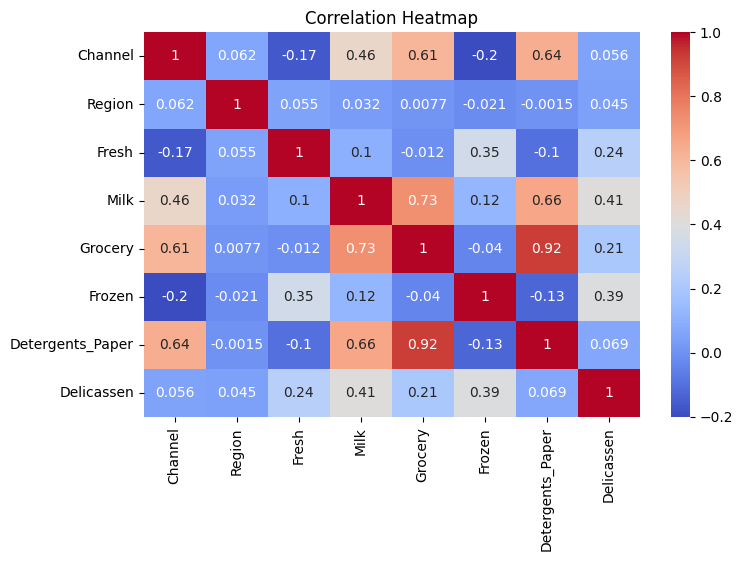

In [38]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [39]:
X = df[['Grocery',
        'Region',]]

print(X.head())

   Grocery  Region
0     7561       3
1     9568       3
2     7684       3
3     4221       3
4     7198       3


In [40]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.04111489  0.59066829]
 [ 0.17031835  0.59066829]
 [-0.0281571   0.59066829]
 [-0.3929769   0.59066829]
 [-0.07935618  0.59066829]]


In [41]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

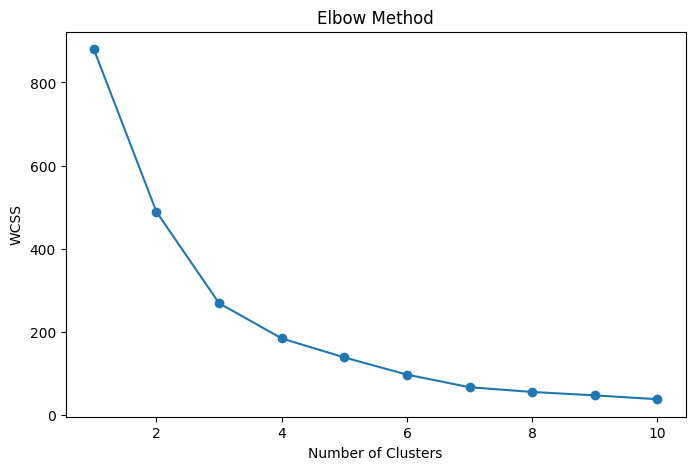

In [42]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [43]:
K = 5

In [44]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [45]:
df['Cluster'] = clusters

print(df.head())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
2        2       3   6353  8808     7684    2405              3516   
3        1       3  13265  1196     4221    6404               507   
4        2       3  22615  5410     7198    3915              1777   

   Delicassen  Cluster  
0        1338        0  
1        1776        0  
2        7844        0  
3        1788        0  
4        5185        0  


In [46]:
score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.6073785848328671


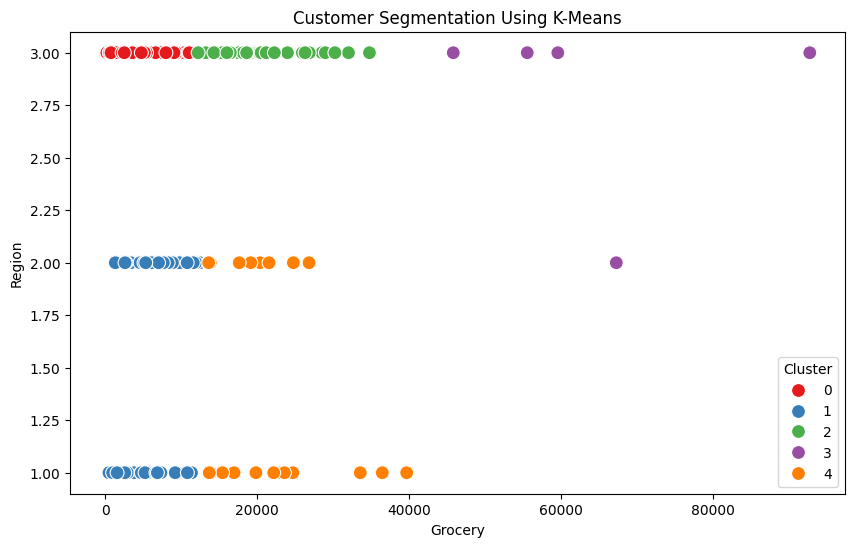

In [48]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Grocery',
    y='Region',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

plt.title("Customer Segmentation Using K-Means")

plt.show()

In [51]:
cluster_summary = df.groupby('Cluster')[
[
    'Grocery',
    'Region',
    'Fresh'
]
].mean()

print(cluster_summary)

              Grocery    Region         Fresh
Cluster                                      
0         4207.463415  3.000000  12665.780488
1         4382.131313  1.373737  11614.717172
2        18279.363636  3.000000  11336.136364
3        64215.000000  2.800000  21035.000000
4        20924.250000  1.375000   6713.833333


In [53]:
print("""
Cluster 0 = High Income, Low Spending
Cluster 1 = High Income, High Spending (VIP)
Cluster 2 = Low Income, Low Spending
Cluster 3 = Average Customers
Cluster 4 = Low Income, High Spending
""")


Cluster 0 = High Income, Low Spending
Cluster 1 = High Income, High Spending (VIP)
Cluster 2 = Low Income, Low Spending
Cluster 3 = Average Customers
Cluster 4 = Low Income, High Spending



In [54]:
joblib.dump(
    kmeans,
    "kmeans_customer_segmentation.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [55]:
new_customer = pd.DataFrame(
    [[70,80]],
    columns=[
        'Grocery',
        'Region'
    ]
)

In [56]:
new_customer

,Grocery,Region
0,70,80


In [57]:
new_customer_scaled = scaler.transform(
    new_customer
)

In [58]:
import joblib

loaded_model = joblib.load(
    "kmeans_customer_segmentation.pkl"
)

In [59]:
prediction = loaded_model.predict(
    new_customer_scaled
)

print("Predicted Cluster:", prediction[0])

Predicted Cluster: 0
